# Export pipeline: dicarlo.Rajalingham2018.public

Public data only; 240-image held-out dataset is chosen here.

This notebook reuses the files already fetched and hash-verified in `02_behavioral_data_inspection.ipynb`


In [ ]:
import hashlib
import json
import os
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import timm
import torch
import xarray as xr
from PIL import Image
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

CACHE_DIR = os.path.expanduser("~/.brainio_manual")
ASSEMBLY_PATH = os.path.join(CACHE_DIR, "assy_dicarlo_Rajalingham2018_public.nc")
STIM_CSV_PATH = os.path.join(CACHE_DIR, "image_dicarlo_objectome_public.csv")
IMG_DIR = os.path.join(CACHE_DIR, "image_dicarlo_objectome_public")  # already fully extracted

OUT_DIR = "data"
os.makedirs(OUT_DIR, exist_ok=True)

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
FEATURES_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "features_2160.npy")
IMAGE_IDS_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "image_ids_2160.json")

assert os.path.exists(ASSEMBLY_PATH), "run 02_behavioral_data_inspection.ipynb first to populate the cache"
assert os.path.isdir(IMG_DIR), "run notebook 02's full image extraction first"
assert sum(name.endswith(".png") for name in os.listdir(IMG_DIR)) == 2160

torch.set_num_threads(os.cpu_count() or 1)
print("cpu threads:", torch.get_num_threads(), "/ cuda available:", torch.cuda.is_available())
# Set True only when you want to discard reuse and recompute all image features.
FORCE_REEXTRACT = False
BATCH_SIZE = 32
FEATURES_METADATA_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "features_2160_meta.json")


Notebook 02 prepares the verified files and all stimulus images. Feature extraction here uses CPU. Run with the notebook folder as your working directory.


## 1. Trial data and stimulus metadata

Dataframe from the assembly rebuilt here (same as
`02_behavioral_data_inspection.ipynb` section 1), and the stimulus/category table (section
2). The 2 malformed trials (`choice` matching neither `sample_obj` nor
`dist_obj`, found during inspection) are excluded here, before anything
downstream: trial counts, accuracy, and the exported trial table all use the
cleaned set, so `n_trials` in `images.parquet` matches what's actually in
`human_trials.parquet`.

In [2]:
assembly = xr.open_dataarray(ASSEMBLY_PATH)
trials_raw = pd.DataFrame({c: assembly.coords[c].values for c in assembly.coords})
trials_raw["correct"] = trials_raw["choice"] == trials_raw["sample_obj"]

malformed_mask = ~(
    (trials_raw["choice"] == trials_raw["sample_obj"])
    | (trials_raw["choice"] == trials_raw["dist_obj"])
)
excluded_trials = trials_raw[malformed_mask].copy()
trials = trials_raw[~malformed_mask].copy()

print(f"raw trials: {len(trials_raw)}")
print(f"excluded (malformed choice): {len(excluded_trials)}")
print(f"exported trials: {len(trials)}")
excluded_trials[["image_id", "sample_obj", "dist_obj", "choice", "WorkerID", "AssignmentID"]]

raw trials: 585511
excluded (malformed choice): 2
exported trials: 585509


,image_id,sample_obj,dist_obj,choice,WorkerID,AssignmentID
115910,bb365d4f14e020dfcdad25142c7324f341c555df,dromedary,lo_poly_animal_RHINO_2,womens_shorts_01M,A3SWGXM2TAC2RL,25IVJ8EBDPGK92ACVTQ90NDWTGP0F0
115916,2acb004a1a3dd0911a7b01c1375c5b331e731faa,womens_stockings_01M,dromedary,lo_poly_animal_RHINO_2,A3SWGXM2TAC2RL,25IVJ8EBDPGK92ACVTQ90NDWTGP0F0


**Malformed-choice exclusion:** 585,509 of 585,511 have valid choices - 2 rows found during inspection are malformed, both from the same worker/session.

In [3]:
stim_df = pd.read_csv(STIM_CSV_PATH)
assert stim_df["image_id"].is_unique, "Duplicate image IDs"
category_map = stim_df.set_index("image_id")["image_label"].to_dict()

assert set(trials["image_id"]).issubset(category_map.keys())
assert set(trials["image_id"]) == set(category_map)
assert (trials["sample_obj"] == trials["image_id"].map(category_map)).all()
assert (trials["sample_obj"] != trials["dist_obj"]).all()
assert set(trials["dist_obj"]).issubset(set(category_map.values()))
assert all(os.path.isfile(os.path.join(IMG_DIR, f"{iid}.png")) for iid in category_map)
print("n images in stimulus set:", len(category_map))
print("n categories:", stim_df["image_label"].nunique())

n images in stimulus set: 2160
n categories: 24


**Every trial has a known category.**<br> 2,160 images across 24 categories, and no image missing from the stimulus set.<br> 
`category_map` - a lookup "dictionary" for `stimulus.csv` is now the single source of truth for ground-truth labels used throughout the rest of this notebook.

## 2. Check: trial count vs. difficulty - the selection criterion

Across all 2160 images, total trial per-image count was correlated against
per-image human accuracy.<br> A correlation would suggest an association between trial count and how easy or hard an image is.<br> Both **Pearson** (linear)
and **Spearman** (monotonic) correlations calculated to check this association.

In [4]:
per_image = (
    trials.groupby("image_id")
    .agg(n_trials=("correct", "size"), accuracy=("correct", "mean"))
    .reset_index()
)
per_image["category"] = per_image["image_id"].map(category_map)
assert len(per_image) == 2160

pearson_r, _ = stats.pearsonr(per_image["n_trials"], per_image["accuracy"])
spearman_r, _ = stats.spearmanr(per_image["n_trials"], per_image["accuracy"])
print(f"Pearson  r = {pearson_r:+.4f}")
print(f"Spearman r = {spearman_r:+.4f}")

Pearson  r = +0.0039
Spearman r = +0.0231


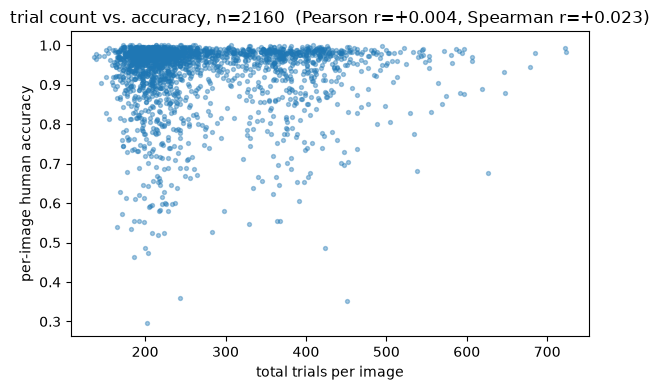

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(per_image["n_trials"], per_image["accuracy"], s=8, alpha=0.4)
ax.set_xlabel("total trials per image")
ax.set_ylabel("per-image human accuracy")
ax.set_title(f"trial count vs. accuracy, n=2160  (Pearson r={pearson_r:+.3f}, Spearman r={spearman_r:+.3f})")
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "diagnostic_trialcount_vs_accuracy.png"), dpi=120)
plt.show()

**Result**: both correlations are near zero:<br>
- Pearson r ≈ +0.004;<br>
- Spearman r ≈ +0.023.<br>

Trial count shows little overall linear or rank relationship to how easy or hard an image is. Proceeding with top 10 images per category with the maximum trial count, while noting that these checks do not prove the selection is unbiased.

## 3. Select the 240 images - held-out dataset

Deterministic: top 10 images per category (24 categories x 10 = 240) ranked
by total trial count (on the cleaned trial set). The remaining 1920 form `probe_train`.

In [6]:
per_image_sorted = per_image.sort_values(
    ["category", "n_trials", "image_id"], ascending=[True, False, True]
)
chosen = per_image_sorted.groupby("category", group_keys=False).head(10)
assert len(chosen) == 240
assert (chosen["category"].value_counts() == 10).all()

scored_ids = set(chosen["image_id"])
per_image["split"] = np.where(per_image["image_id"].isin(scored_ids), "scored", "probe_train")
print(per_image["split"].value_counts())
print()
print("trial-count range of the held-out set - 240:", chosen["n_trials"].min(), "-", chosen["n_trials"].max())
print("trial-count range of the training set - 1920:",
      per_image.loc[per_image["split"] == "probe_train", "n_trials"].min(), "-",
      per_image.loc[per_image["split"] == "probe_train", "n_trials"].max())

split
probe_train    1920
scored          240
Name: count, dtype: int64

trial-count range of the held-out set - 240: 381 - 723
trial-count range of the training set - 1920: 137 - 425


**Result:** 240 `scored` (10 per category) / 1920 `probe_train` (80 per category). The held-out set of 240 images has 381-723 trials each VS 137-425 for the rest. This confirms the "top trial count" criterion was implemented successfully.

## 4. Per-cell trial distribution for the held-out set (240)

Cells are `(image_id, distractor)` pairs. Image-level trial totals hide the
floor that actually matters downstream: a 1-trial cell has raw accuracy of exactly 0 or
1 (without correction, the inverse-normal transform sends it to infinity), and a 2-trial cell
only splits into two 1-trial halves, each with a raw rate of 0 or 1. Notebook 04 retains cells with at least four trials so each half has at least two responses.

In [7]:
scored_trials = trials[trials["image_id"].isin(scored_ids)]
cell_counts = scored_trials.groupby(["image_id", "dist_obj"]).size()

print(f"n cells (image_id x distractor) observed: {len(cell_counts)}")
print("min trials in any cell:", cell_counts.min())
print()
for th in (3, 4, 5, 6):
    n_below = int((cell_counts < th).sum())
    print(f"cells with < {th} trials: {n_below}  ({n_below / len(cell_counts):.1%})")

n cells (image_id x distractor) observed: 5519
min trials in any cell: 1

cells with < 3 trials: 18  (0.3%)
cells with < 4 trials: 46  (0.8%)
cells with < 5 trials: 73  (1.3%)
cells with < 6 trials: 127  (2.3%)


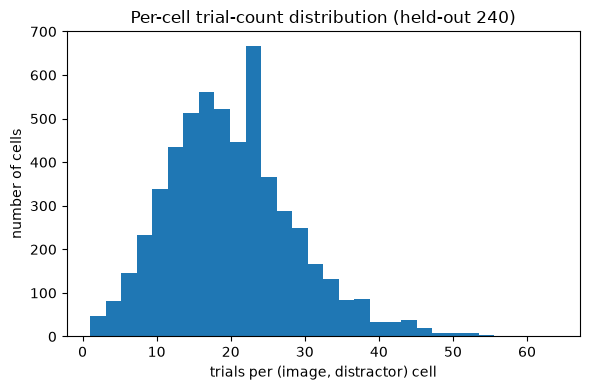

In [8]:
plt.figure(figsize=(6, 4))
plt.hist(cell_counts, bins=30)
plt.xlabel("trials per (image, distractor) cell")
plt.ylabel("number of cells")
plt.title("Per-cell trial-count distribution (held-out 240)")
plt.tight_layout()
plt.show()

**Low trial counts:**: <br>
- min is 1 trial - the 1-trial cells can't be split into two halves at all (one side
would be empty);<br>
- 2-trial cells split into two degenerate 1-trial halves, both giving raw rates of 0 or 1 before correction.<br>
- 18 cells in total has less than 3 trials<br>
- 46 cells have fewer than 4 trials; these are dropped in notebook 04, leaving 5,473 cells.<br>

Splitting each cell's trials in half gives two estimates from the available trials, so by how well the two halves "agree", we can tell how reliable human data itself is.<br>

This is reported here as specified; handling it (clipping, smoothing, or exclusion) happens later, in
`04_i2n_analysis.ipynb`. <br>

This notebook just hands over `n_trials` and the raw trials so that stage can see the same floor.

## 5. Cell coverage within the held-out set (240)

240 images x 23 possible distractors (24 categories - 1, the image's own
category) = 5,520 maximum cells. This is the same figure the Brain-Score
paper quotes for its image-wise analysis.

In [9]:
n_cells_observed = len(cell_counts)
n_cells_max = 240 * 23
n_missing = n_cells_max - n_cells_observed
print(f"observed cells: {n_cells_observed} / {n_cells_max} max  ({n_missing} missing)")

# Which (image_id, distractor) combinations never occurred at all
observed_pairs = set(cell_counts.index)
all_categories = sorted(set(category_map.values()))
missing_pairs = []
for _, row in chosen.iterrows():
    img_cats = [c for c in all_categories if c != row["category"]]
    for dist_cat in img_cats:
        if (row["image_id"], dist_cat) not in observed_pairs:
            missing_pairs.append((row["image_id"], row["category"], dist_cat))

print(f"missing pairs: {len(missing_pairs)}")
missing_pairs

observed cells: 5519 / 5520 max  (1 missing)
missing pairs: 1


[('8ef3c6a907e0014730e454a27f4f73a32d32f617',
  'weimaraner',
  'interior_details_130_2')]

Landing at 5,519 / 5,520 - one missing cell - `image_id`: `8ef3c6a907e0014730e454a27f4f73a32d32f617`.<br>

Brain-Score paper's quoted cell count to confirm the setup (240-images x 23-distractors design) is reconstructed correctly.

## 6. Model setup, preprocessing, and determinism check

For this project, we are using the variant established for this project:<br>`eva02_base_patch14_448.mim_in22k_ft_in22k_in1k`, see `01_EVA-02_model_inspection.ipynb`.

**Preprocessing note:** the stimulus images are provided in 224x224px size, but this model expects 448x448px inpit - the `transform` built below resizes every image up to that size using bicubic interpolation (a smooth upscale that estimates each new pixel from a 4x4 neighbourhood of original pixels, not a crop) before it's fed to the model.

In [10]:
import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR) 

model_name = "eva02_base_patch14_448.mim_in22k_ft_in22k_in1k"
model = timm.create_model(model_name, pretrained=True)
model.eval()

data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)
print("data_config:", {k: data_config[k] for k in ("input_size", "interpolation", "crop_mode")})

# Confirm feature dimensionality 
dummy = torch.randn(1, *data_config["input_size"])
with torch.no_grad():
    feat_map = model.forward_features(dummy)
    pooled = model.forward_head(feat_map, pre_logits=True)
FEATURE_DIM = pooled.shape[-1]
print("forward_features shape:", feat_map.shape)
print("pre_logits pooled shape:", pooled.shape, "-> FEATURE_DIM =", FEATURE_DIM)

data_config: {'input_size': (3, 448, 448), 'interpolation': 'bicubic', 'crop_mode': 'squash'}


forward_features shape: torch.Size([1, 1025, 768])
pre_logits pooled shape: torch.Size([1, 768]) -> FEATURE_DIM = 768


**Input/Output dimensions:**<br>
- original input: 224x224,<br>
- resized input: 448x448,<br>
- 768-d pre-logits output,<br>
matching `01_EVA-02_model_inspection.ipynb`.

### 6.1 Verifying determinism

The noise-ceiling assumption (`rss = 1`) used later in `04_i2n_analysis.ipynb`
comes from the model data being deterministic. To verify this assumption, a handful of images is run through the full pipeline twice, requiring bit-identical output.

In [11]:
check_files = sorted(n for n in os.listdir(IMG_DIR) if n.endswith(".png"))[:8]
check_ids = [f[:-4] for f in check_files]

def extract_batch(image_ids):
    imgs = []
    for iid in image_ids:
        with Image.open(os.path.join(IMG_DIR, iid + ".png")) as im:
            imgs.append(im.convert("RGB"))
    batch = torch.stack([transform(im) for im in imgs])
    with torch.no_grad():
        feats = model.forward_features(batch)
        pooled = model.forward_head(feats, pre_logits=True)
    return pooled

run1 = extract_batch(check_ids)
run2 = extract_batch(check_ids)
identical = torch.equal(run1, run2)
max_abs_diff = (run1 - run2).abs().max().item()
print(f"bit-identical across two runs: {identical}  (max abs diff: {max_abs_diff:.3e})")
assert identical, "model is not deterministic -- the rss=1 assumption would be unsafe"

bit-identical across two runs: True  (max abs diff: 0.000e+00)


Two independent forward passes on the same 8 images produce bit-identical output (max abs diff 0.0).<br> This supports `rss = 1` for the fixed model and readout used later in `04_i2n_analysis.ipynb`.

## 7. Feature extraction and cache validation

Images have a fixed sorted-ID order. A metadata-backed cache is checked against the
current weights, preprocessing, versions and its own file hash. An older cache without
metadata can be reused only after shape/ID checks and agreement on the eight freshly
extracted examples. Such reuse is explicitly recorded as a partial validation of a
legacy cache, with unknown original extraction time. Set `FORCE_REEXTRACT = True`
above if its origin is uncertain and you want a completely fresh extraction.


In [12]:
def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

weights_digest = hashlib.sha256()
for name, tensor in model.state_dict().items():
    weights_digest.update(name.encode("utf-8"))
    weights_digest.update(str((tuple(tensor.shape), tensor.dtype)).encode("utf-8"))
    raw = tensor.detach().cpu().contiguous().reshape(-1).view(torch.uint8).numpy()
    weights_digest.update(raw.tobytes())

extraction_config = {
    "model_name": model_name,
    "weights_sha256": weights_digest.hexdigest(),
    "timm_version": timm.__version__,
    "torch_version": torch.__version__,
    "feature_dim": int(FEATURE_DIM),
    "data_config": data_config,
}
# Round-trip tuples to JSON lists for stable comparison on later runs.
extraction_config = json.loads(json.dumps(extraction_config))
all_image_ids = sorted(category_map)
assert len(all_image_ids) == 2160
feature_metadata = None
features_arr = None
check_positions = [all_image_ids.index(iid) for iid in check_ids]
fresh_check = run1.detach().cpu().numpy()

if not FORCE_REEXTRACT and os.path.isfile(FEATURES_CHECKPOINT) and os.path.isfile(IMAGE_IDS_CHECKPOINT):
    try:
        with open(IMAGE_IDS_CHECKPOINT) as stream:
            cached_ids = json.load(stream)
        candidate = np.load(FEATURES_CHECKPOINT, allow_pickle=False)
        valid = (cached_ids == all_image_ids
                 and candidate.shape == (2160, FEATURE_DIM)
                 and np.isfinite(candidate).all())
        if os.path.isfile(FEATURES_METADATA_CHECKPOINT):
            with open(FEATURES_METADATA_CHECKPOINT) as stream:
                metadata = json.load(stream)
            valid = (valid and metadata.get("validated_against") == extraction_config
                     and metadata.get("features_sha256") == file_sha256(FEATURES_CHECKPOINT))
        else:
            metadata = {
                "origin": "legacy_cache_checked_on_8_images",
                "extracted_at_utc": None,
            }
        if valid:
            valid = np.allclose(candidate[check_positions], fresh_check, rtol=1e-4, atol=1e-5)
        if valid:
            features_arr = candidate
            feature_metadata = metadata
            print("Reusing validated cache:", candidate.shape, metadata["origin"])
        else:
            print("Cache did not match the current extraction; recomputing features.")
    except (OSError, ValueError, KeyError, TypeError) as exc:
        print("Cache could not be validated; recomputing features:", str(exc))

if features_arr is None:
    feature_rows = []
    started = datetime.now(timezone.utc)
    for start in range(0, len(all_image_ids), BATCH_SIZE):
        batch_ids = all_image_ids[start:start + BATCH_SIZE]
        pooled = extract_batch(batch_ids)
        feature_rows.append(pooled.detach().cpu().numpy().astype(np.float64))
        if (start // BATCH_SIZE) % 20 == 0:
            elapsed = (datetime.now(timezone.utc) - started).total_seconds()
            print(f"{start + len(batch_ids):4d} / {len(all_image_ids)} ({elapsed:.1f}s)")
    features_arr = np.concatenate(feature_rows, axis=0)
    assert features_arr.shape == (2160, FEATURE_DIM)
    assert np.isfinite(features_arr).all()
    np.save(FEATURES_CHECKPOINT, features_arr)
    with open(IMAGE_IDS_CHECKPOINT, "w") as stream:
        json.dump(all_image_ids, stream)
    feature_metadata = {"origin": "fresh_extraction", "extracted_at_utc": started.isoformat()}

assert features_arr.shape == (2160, FEATURE_DIM)
assert np.isfinite(features_arr).all()
feature_metadata.update({
    "validated_against": extraction_config,
    "features_sha256": file_sha256(FEATURES_CHECKPOINT),
    "last_validation_utc": datetime.now(timezone.utc).isoformat(),
    "n_fresh_examples_checked": len(check_ids),
})
with open(FEATURES_METADATA_CHECKPOINT, "w") as stream:
    json.dump(feature_metadata, stream, indent=2)
print("Feature matrix ready:", features_arr.shape)


Reusing validated cache: (2160, 768) legacy_cache_checked_on_8_images
Feature matrix ready: (2160, 768)


This run reused the existing feature cache after checking its shape, image IDs and agreement with eight freshly extracted examples. Its original extraction date is unknown; the metadata records the checks made during this run.


## 8. Export

Three parquet files (`pyarrow`) - parquet instead of CSV because it stores each column's real dtype (no re-parsing 768 float columns from text) and is smaller and faster to read.

- `features.parquet`: one 768-d feature vector per image
- `images.parquet`: per-image category, split (`scored`/`probe_train`), and trial count
- `human_trials.parquet`: every individual human trial (target, distractor, correct, subject, session)

In [13]:
# --- features.parquet: all 2160, one row per image ---
n_digits = len(str(FEATURE_DIM))
feature_cols = [f"f{i+1:0{n_digits}d}" for i in range(FEATURE_DIM)]
features_df = pd.DataFrame(features_arr, columns=feature_cols)
features_df.insert(0, "image_id", all_image_ids)

pq.write_table(pa.Table.from_pandas(features_df, preserve_index=False),
                os.path.join(OUT_DIR, "features.parquet"))
print("features.parquet:", features_df.shape)

features.parquet: (2160, 769)


features.parquet dimension: 2160 images x 768-d vector (+image_id column)

In [14]:
# --- images.parquet: all 2160, one row per image ---
images_df = per_image[["image_id", "category", "split", "n_trials"]].copy()
images_df["n_trials"] = images_df["n_trials"].astype("int64")
images_df = images_df.sort_values("image_id").reset_index(drop=True)

assert len(images_df) == 2160
assert set(images_df["split"]) == {"probe_train", "scored"}
assert (images_df["split"] == "scored").sum() == 240

pq.write_table(pa.Table.from_pandas(images_df, preserve_index=False),
                os.path.join(OUT_DIR, "images.parquet"))
print("images.parquet:", images_df.shape)
images_df.head()

images.parquet: (2160, 4)


,image_id,category,split,n_trials
0,0020cef91bd626e9fbbabd853494ee444e5c9ecb,flarenut_spanner,scored,403
1,00a313fc5929bb79e49ead5de202a317eeafe659,dromedary,scored,417
2,00c6269c951f5ce5bf0a77c45c5e6fb3d2ec694e,MB29874,probe_train,179
3,00e9fb160a10345d5a27850c946195724583514b,MB29874,probe_train,268
4,0119aa4a7957d1db7f4e6803f00d3868eb8e028b,interior_details_130_2,probe_train,216


In [15]:
# --- human_trials.parquet: all exported trials (585,511 - 2 malformed = 585,509) ---
human_trials_df = pd.DataFrame({
    "image_id": trials["image_id"].values,
    "target": trials["sample_obj"].values,
    "distractor": trials["dist_obj"].values,
    "correct": trials["correct"].values.astype(bool),
    "subject_id": trials["WorkerID"].values,
    "session_id": trials["AssignmentID"].values,
})

assert len(human_trials_df) == len(trials_raw) - len(excluded_trials)

pq.write_table(pa.Table.from_pandas(human_trials_df, preserve_index=False),
                os.path.join(OUT_DIR, "human_trials.parquet"))
print("human_trials.parquet:", human_trials_df.shape)

human_trials.parquet: (585509, 6)


In [16]:
# --- export_info.json ---
manifest = {
    "assembly": "dicarlo.Rajalingham2018.public",
    "export_date_utc": datetime.now(timezone.utc).isoformat(),
    "extraction_date_utc": feature_metadata["extracted_at_utc"],
    "feature_provenance": feature_metadata,
    "model": {
        "variant": model_name,
        "timm_version": timm.__version__,
        "torch_version": torch.__version__,
        "python_version": platform.python_version(),
        "input_resolution": f"{data_config['input_size'][1]}x{data_config['input_size'][2]}",
        "input_channels": data_config["input_size"][0],
        "feature_dim": int(FEATURE_DIM),
        "preprocessing": {
            "interpolation": data_config["interpolation"],
            "crop_pct": data_config["crop_pct"],
            "crop_mode": data_config["crop_mode"],
            "mean": data_config["mean"],
            "std": data_config["std"],
            "masking": "none -- full-bleed 224x224 greyscale photos, no circular mask (corrected from original brief)",
        },
        "determinism_check": {
            "n_images_checked": len(check_ids),
            "bit_identical_across_two_runs": bool(identical),
            "max_abs_diff": float(max_abs_diff),
        },
    },
    "counts": {
        "n_images_total": 2160,
        "n_images_probe_train": 1920,
        "n_images_scored": 240,
        "n_categories": 24,
        "n_trials_raw": int(len(trials_raw)),
        "n_trials_excluded": int(len(excluded_trials)),
        "n_trials_exported": int(len(human_trials_df)),
    },
    "selection": {
        "criterion": "top 10 images per category (24 categories) by total human trial count "
                     "(computed on trials after excluding the 2 malformed-choice trials), "
                     "ties broken by image_id ascending; deterministic, no seed",
        "gate_check": {
            "description": "correlation between per-image trial count and per-image human accuracy, "
                            "across all 2160 images, computed before selecting the 240",
            "pearson_r": float(pearson_r),
            "spearman_r": float(spearman_r),
            "result": "descriptive association check; does not establish unbiased selection",
        },
    },
    "excluded_trials": [
        {
            "image_id": str(row["image_id"]),
            "sample_obj": str(row["sample_obj"]),
            "dist_obj": str(row["dist_obj"]),
            "choice": str(row["choice"]),
            "subject_id": str(row["WorkerID"]),
            "session_id": str(row["AssignmentID"]),
            "reason": "choice matches neither sample_obj nor dist_obj",
        }
        for _, row in excluded_trials.iterrows()
    ],
    "diagnostics": {
        "cell_coverage_within_scored_240": {
            "n_cells_observed": int(n_cells_observed),
            "n_cells_max": int(n_cells_max),
            "n_cells_missing": int(n_missing),
            "missing_pairs": [
                {"image_id": iid, "image_category": cat, "missing_distractor": dist}
                for iid, cat, dist in missing_pairs
            ],
        },
        "per_cell_trial_counts_within_scored_240": {
            "min": int(cell_counts.min()),
            "q25": float(cell_counts.quantile(0.25)),
            "median": float(cell_counts.median()),
            "q75": float(cell_counts.quantile(0.75)),
            "max": int(cell_counts.max()),
            "n_below_3": int((cell_counts < 3).sum()),
            "n_below_4": int((cell_counts < 4).sum()),
            "n_below_5": int((cell_counts < 5).sum()),
            "n_below_6": int((cell_counts < 6).sum()),
        },
    },
}

with open(os.path.join(OUT_DIR, "export_info.json"), "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2)[:2000], "...")

{
  "assembly": "dicarlo.Rajalingham2018.public",
  "export_date_utc": "2026-09-10T10:31:21.722339+00:00",
  "extraction_date_utc": null,
  "feature_provenance": {
    "origin": "legacy_cache_checked_on_8_images",
    "extracted_at_utc": null,
    "validated_against": {
      "model_name": "eva02_base_patch14_448.mim_in22k_ft_in22k_in1k",
      "weights_sha256": "3c30b6c269c55efecbaf1b53fe5b3e447e59730d66dfd8962fc1fab730a9fa8a",
      "timm_version": "1.0.28",
      "torch_version": "2.13.0+cu126",
      "feature_dim": 768,
      "data_config": {
        "input_size": [
          3,
          448,
          448
        ],
        "interpolation": "bicubic",
        "mean": [
          0.48145466,
          0.4578275,
          0.40821073
        ],
        "std": [
          0.26862954,
          0.26130258,
          0.27577711
        ],
        "crop_pct": 1.0,
        "crop_mode": "squash"
      }
    },
    "features_sha256": "f480c70a3c6b18598e85853cdd488a5c85174210d0b21cb3f20068

## Summary

- Gate check (section 2): Pearson r ≈ +0.004, Spearman r ≈ +0.023
  — little overall linear or rank association between trial count and difficulty; this does not prove unbiased selection. Proceeded with top-10-per-category.
- Selected 240 = top 10 per category by trial count (24 x 10).
- Per-cell count (section 4): min 1 trial/cell, 18 cells below 3 trials -
  flagged here, handled in `04_i2n_analysis.ipynb`.
- Cell coverage (section 5): 5,519 / 5,520 possible cells observed - confirms the
  240x23 design matches the Brain-Score paper's own image-wise cell count.
- Determinism confirmed bit-identical across two runs for model data.
- **Output files:** `data/features.parquet`, `data/images.parquet`,
  `data/human_trials.parquet`, `data/export_info.json`.
